# Model Interpretation

## Objective

The objective of this phase is to interpret the final machine learning model and identify the features that have the greatest influence on customer churn predictions.

The analysis will focus on:

- Model coefficients
- Feature importance
- Positive and negative relationships with churn
- Business interpretation
- Customer retention insights

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.inspection import permutation_importance

In [2]:
# Load cleaned dataset

df = pd.read_csv("../data/processed/customer_churn_clean.csv")

# Remove customer identifier

df = df.drop(columns=["customerID"])

# Separate features and target

X = df.drop(columns=["Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1})

In [3]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [4]:
# Define categorical and numerical features

categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

In [5]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

# Create final Logistic Regression pipeline

final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                C=100,
                max_iter=1000
            )
        )
    ]
)

# Train final model

final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

## Logistic Regression Coefficients

Logistic Regression provides interpretable coefficients.

A positive coefficient indicates that the corresponding feature is associated with a higher probability of churn, while a negative coefficient indicates an association with a lower probability of churn.

Because categorical variables were encoded using One-Hot Encoding, each category receives its own coefficient.

In [6]:
# Extract transformed feature names

feature_names = final_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Extract model coefficients

coefficients = final_model.named_steps[
    "model"
].coef_[0]

# Create coefficient dataframe

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df["AbsoluteCoefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "AbsoluteCoefficient",
    ascending=False
)

display(coefficient_df.head(20))

,Feature,Coefficient,AbsoluteCoefficient
1,numerical__MonthlyCharges,-2.259921,2.259921
17,categorical__InternetService_Fiber optic,1.416351,1.416351
0,numerical__tenure,-1.406623,1.406623
16,categorical__InternetService_DSL,-1.206949,1.206949
39,categorical__Contract_Two year,-0.819993,0.819993
2,numerical__TotalCharges,0.698858,0.698858
18,categorical__InternetService_No,-0.633016,0.633016
23,categorical__OnlineBackup_No internet service,-0.633016,0.633016
29,categorical__TechSupport_No internet service,-0.633016,0.633016
26,categorical__DeviceProtection_No internet service,-0.633016,0.633016


## Features Associated With Higher Churn

The features with the largest positive coefficients are associated with a higher probability of customer churn.

These variables can provide useful insights into customer profiles that may require retention strategies.

In [7]:
# Display features associated with higher churn

positive_features = (
    coefficient_df[
        coefficient_df["Coefficient"] > 0
    ]
    .sort_values("Coefficient", ascending=False)
    .head(15)
)

display(positive_features)

,Feature,Coefficient,AbsoluteCoefficient
17,categorical__InternetService_Fiber optic,1.416351,1.416351
2,numerical__TotalCharges,0.698858,0.698858
33,categorical__StreamingTV_Yes,0.591581,0.591581
37,categorical__Contract_Month-to-month,0.578978,0.578978
36,categorical__StreamingMovies_Yes,0.578544,0.578544
15,categorical__MultipleLines_Yes,0.380225,0.380225
27,categorical__DeviceProtection_Yes,0.291983,0.291983
24,categorical__OnlineBackup_Yes,0.188347,0.188347
44,categorical__PaymentMethod_Electronic check,0.152421,0.152421
19,categorical__OnlineSecurity_No,0.141088,0.141088


## Features Associated With Lower Churn

The features with the most negative coefficients are associated with a lower probability of customer churn.

These characteristics may represent factors related to customer retention.

In [8]:
# Display features associated with lower churn

negative_features = (
    coefficient_df[
        coefficient_df["Coefficient"] < 0
    ]
    .sort_values("Coefficient")
    .head(15)
)

display(negative_features)

,Feature,Coefficient,AbsoluteCoefficient
1,numerical__MonthlyCharges,-2.259921,2.259921
0,numerical__tenure,-1.406623,1.406623
16,categorical__InternetService_DSL,-1.206949,1.206949
39,categorical__Contract_Two year,-0.819993,0.819993
18,categorical__InternetService_No,-0.633016,0.633016
23,categorical__OnlineBackup_No internet service,-0.633016,0.633016
29,categorical__TechSupport_No internet service,-0.633016,0.633016
26,categorical__DeviceProtection_No internet service,-0.633016,0.633016
20,categorical__OnlineSecurity_No internet service,-0.633016,0.633016
32,categorical__StreamingTV_No internet service,-0.633016,0.633016


## Model Coefficient Visualization

The following visualization highlights the features with the strongest relationships with the churn prediction.

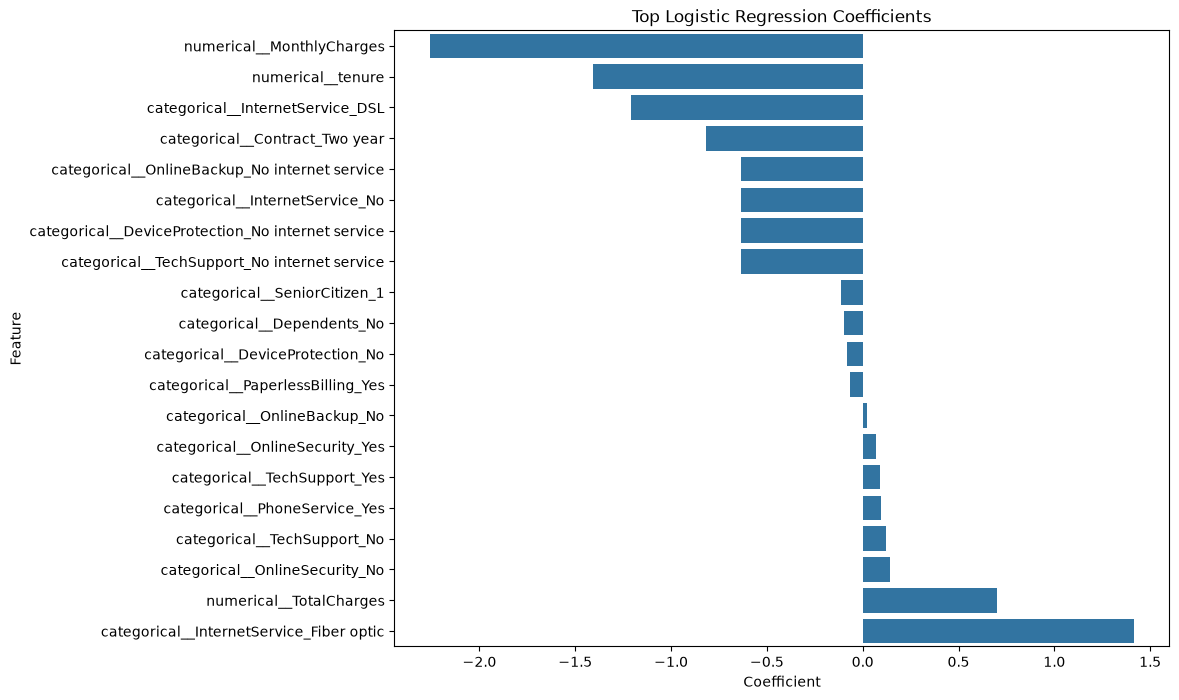

In [9]:
# Select strongest positive and negative coefficients

top_coefficients = pd.concat([
    coefficient_df.head(10),
    coefficient_df.tail(10)
])

top_coefficients = top_coefficients.sort_values(
    "Coefficient"
)

# Plot coefficients

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

## Permutation Importance

Permutation importance measures how much model performance decreases when the values of a feature are randomly shuffled.

A larger decrease in performance indicates that the model relies more heavily on that feature.

This approach provides a model-agnostic perspective of feature importance.

In [10]:
# Calculate permutation importance

permutation = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Create feature importance dataframe

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": permutation.importances_mean
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

display(importance_df)

,Feature,Importance
4,tenure,0.198432
7,InternetService,0.150625
17,MonthlyCharges,0.121641
14,Contract,0.033450
12,StreamingTV,0.024862
13,StreamingMovies,0.024739
18,TotalCharges,0.024105
6,MultipleLines,0.012634
9,OnlineBackup,0.007557
8,OnlineSecurity,0.007311


## Feature Importance

The following visualization shows the features that have the greatest impact on the model's ROC-AUC performance when their values are randomly shuffled.

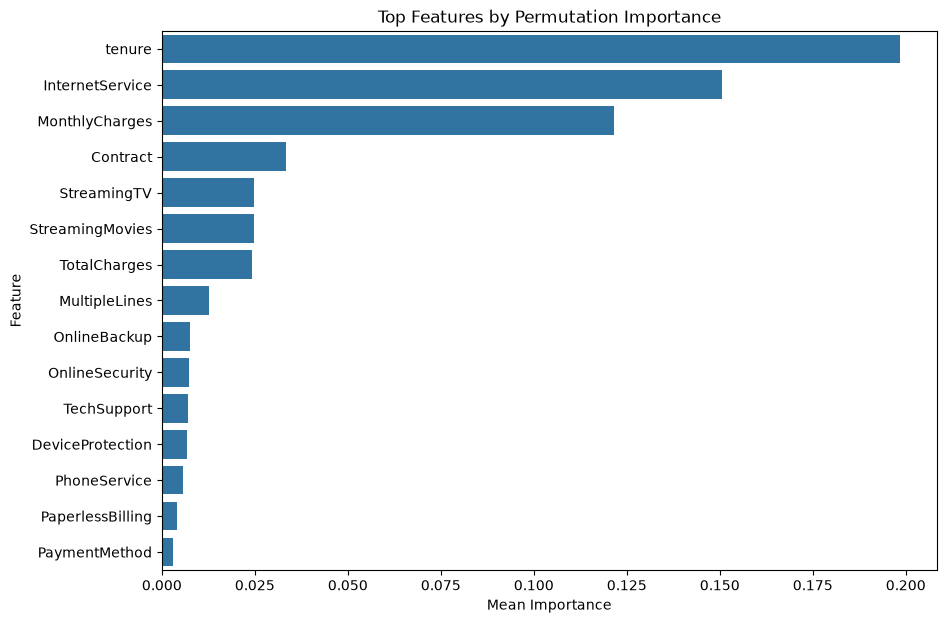

In [11]:
# Select top features

top_importance = importance_df.head(15)

# Plot feature importance

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_importance,
    x="Importance",
    y="Feature"
)

plt.title("Top Features by Permutation Importance")
plt.xlabel("Mean Importance")
plt.ylabel("Feature")

plt.show()

In [12]:
# Save the final trained pipeline

import joblib

joblib.dump(
    final_model,
    "../models/churn_logistic_regression.pkl"
)

print("Model saved successfully.")

Model saved successfully.


## Business Interpretation

The model interpretation provides insight into the characteristics associated with customer churn.

The identified features should not be interpreted as proof of causation. Instead, they indicate patterns that the model uses when distinguishing between customers who churn and those who remain.

These insights can support customer retention strategies and help prioritize customers for further analysis.

## Business Questions

The following questions will be addressed using the model interpretation results:

1. Which customer characteristics are most strongly associated with churn?

2. Which characteristics are associated with customer retention?

3. Which customer profiles should the company prioritize for retention campaigns?

4. Are contract type and tenure important predictors of churn?

5. Which services or customer characteristics appear to be associated with higher churn risk?

6. How can these findings support customer retention strategies?